`ggplot2` has a different phylosophy of creating graphs than `lattice`. In `lattice` we have predefined functions that we can use to draw data. In `ggplot2` we have a main function `ggplot()` where we input all the main data we want to be inside the graph, to which we add addidional parts as layers using `+`. So calling out `ggplot(data)` will give us just an the bare sceleton with axises, but `ggplot(data) + geom_point()` will add all of the points of data on the graph as points. An important part of any `ggplot` is the astethics of mapping `aes()` where you give the information on how the data should be presented. You define the independant and dependant variable (as `x` and `y`) but also the colors, labels and any visual aspect of the graph. If you add `aes()` into the main call to the `ggplot()` function, it will be shared through all layers, but you can add specific `aes()` for each layer. Most drawing is done by adding geometry layers. `geom_point` presents data as points, `geom_smooth` as a line, `goem_violin` as a violin plot, `boxplot` as an box and whiskers plot.   
The next few exercises use the data from the "countries.csv".Using the function `ggplot()` from the package `ggplot2`, create a point graph in which the axises of the graph are related to the birth and death rate in countries, each point is of a size related to the size of the population of the country it represents and the color of the point is related to the continent from which it is from.

In [ ]:
countries = read.csv2('Data/countries.csv')
countries

country,birth.rate,death.rate,population,continent
<chr>,<dbl>,<dbl>,<int>,<chr>
Afghanistan,34.1,7.7,30552,Asia
Albania,12.9,9.4,3173,Europe
Algeria,24.3,5.7,39208,Africa
Andorra,8.9,8.4,79,Europe
Angola,44.1,13.9,21472,Africa
Antigua and Barbuda,16.5,6.8,90,Americas
Argentina,16.8,7.6,41446,Americas
Armenia,13.7,12.6,2977,Asia
Australia,13.2,6.4,23343,Oceania


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


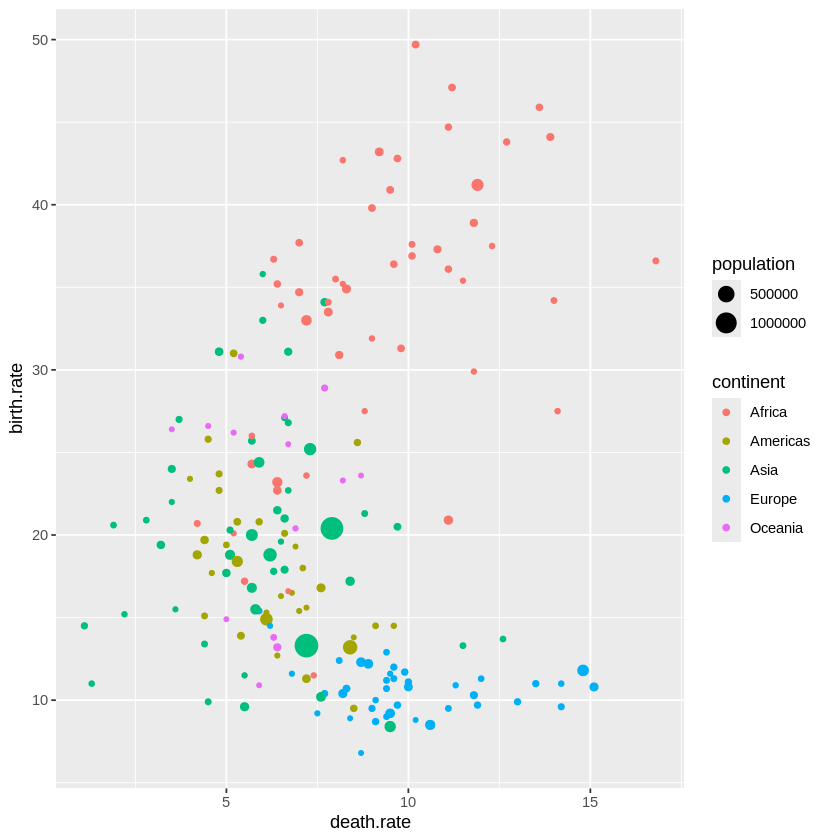

In [3]:
library(ggplot2)

ggplot(countries, aes(death.rate, birth.rate, colour=continent, size=population)) + geom_point()

To see how colours are differently applied if the variable used to a continuous variable create a similar graph with the independent variable being the birth rate, and the dependent variable being the death rate of the country, where the color of the point is dependent on the birth rate, and all sizes of the point are 2.

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


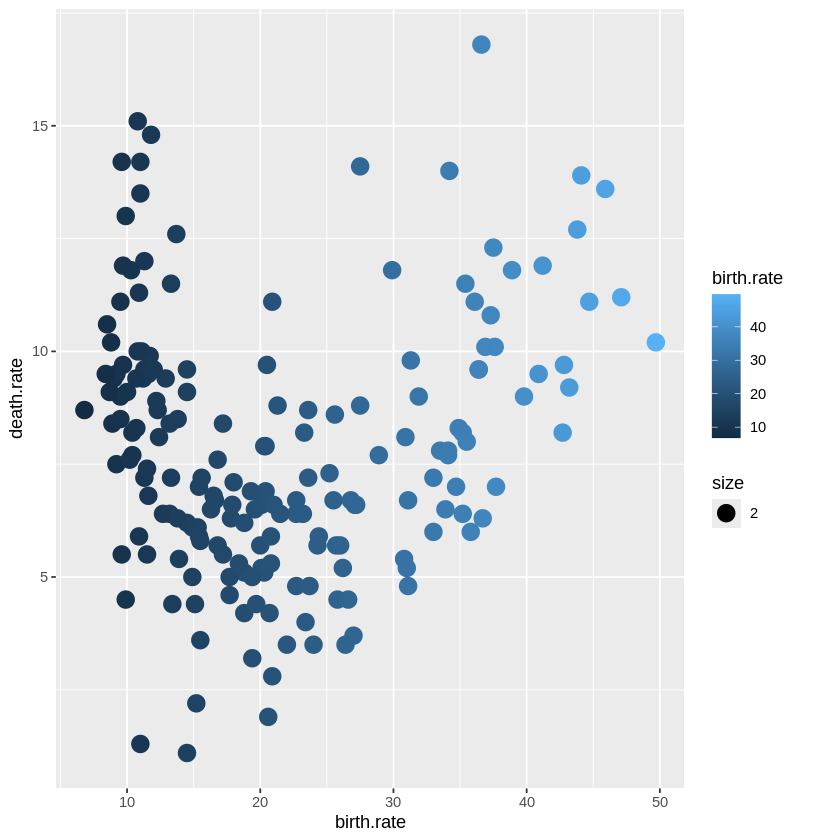

In [4]:
ggplot(countries, aes(birth.rate, death.rate, colour=birth.rate, size=2)) + geom_point()

Using the function `ggplot` from the package `ggplot2`, create a graph with the independent variable being the continents on which the countries lie, and the dependent variable being the birth rate of the country, which combines the dependencies in the form of a box plot, violin plot and a dot plot on one graph.

Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


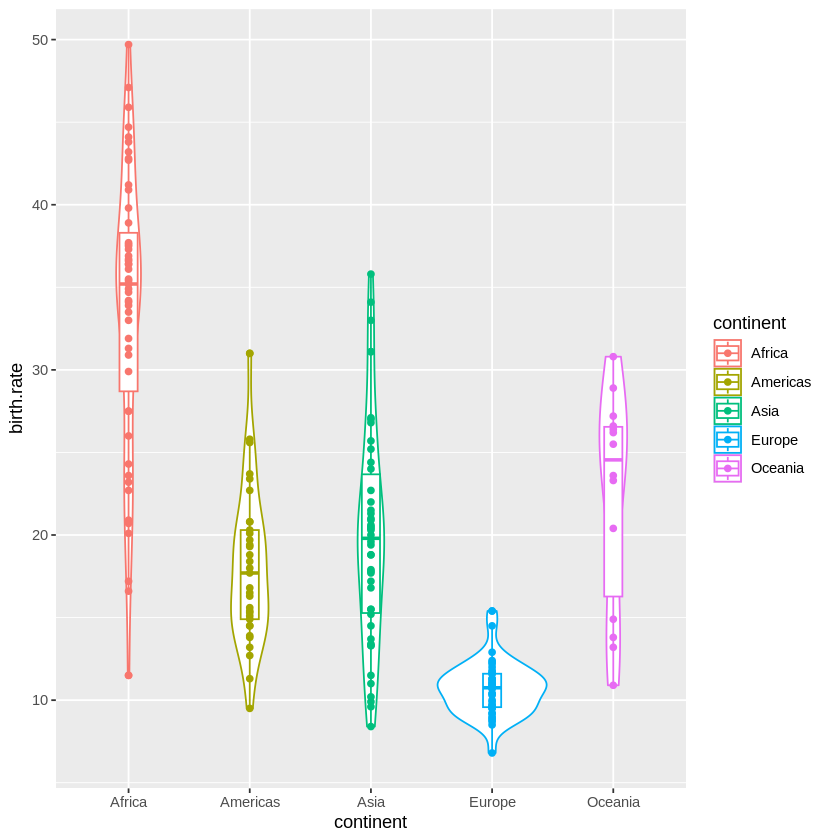

In [27]:
ggplot(countries, aes(x = continent, y = birth.rate, color=continent)) +
  geom_violin() +
  geom_boxplot(width = 0.15) +
  geom_point()

We can define different forms of dots presented by the graph, by using `scale_shape_manual` and `scale_shape_discrete`. Using the function `ggplot` from the package `ggplot2`, create two graphs with the independent variable being the birth rate, and the dependent variable being the death rate of the country, each point should represent the continent from which the country origins. In one graph the continents should be represented by capital letters, in the second by hollow shapes.



Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


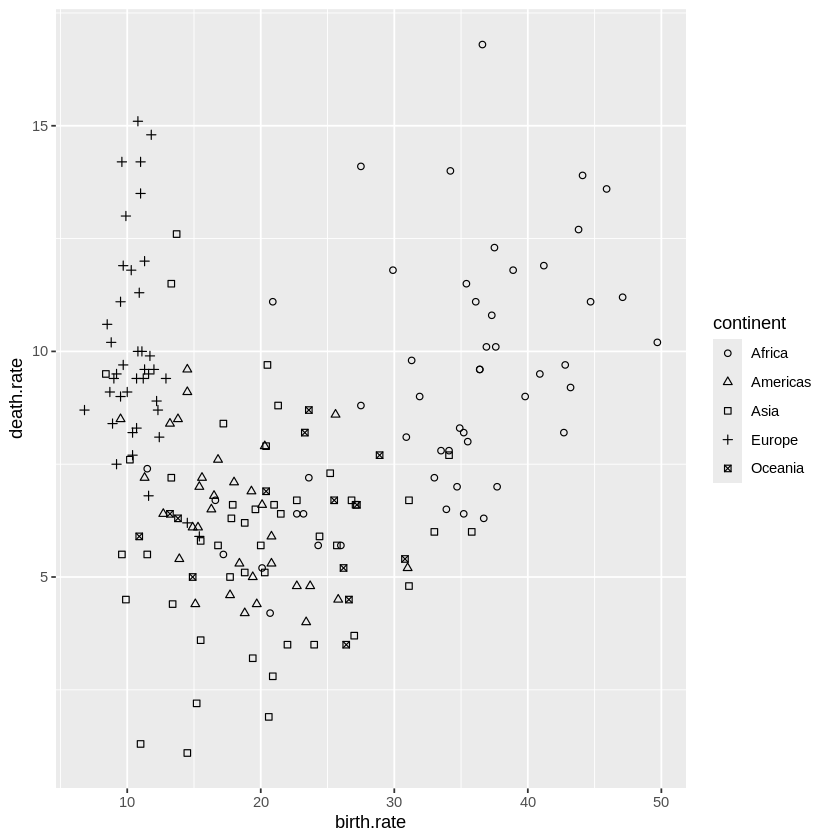

In [28]:
ggplot(countries, aes(birth.rate, death.rate)) + geom_point(aes(shape=continent)) + scale_shape_discrete(solid=FALSE)

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


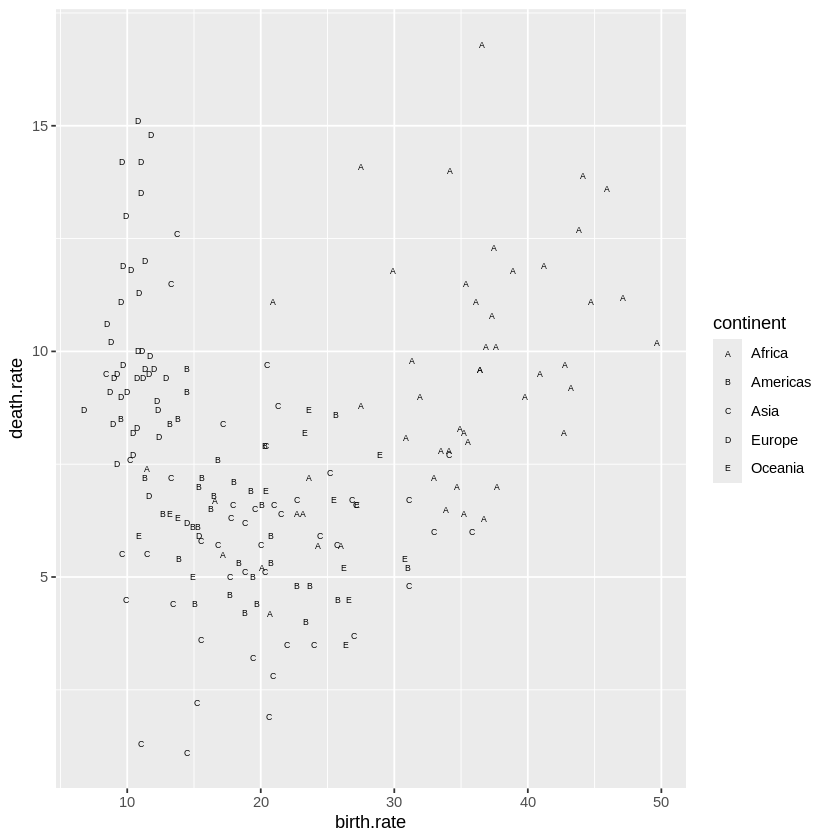

In [29]:
ggplot(countries, aes(birth.rate, death.rate)) + geom_point(aes(shape=continent)) + scale_shape_manual(values=LETTERS)

We can also aggregate the data into subgroups presented on separate graphs next to each other in one row using the function `viewport()` from the package `grid`. Using the function `ggplot` from the package `ggplot2`, create five graphs next to each other with the independent variable being the birth rate, and the dependent variable being the death rate of the country, were you display the data for each continent separately for each country as a point of the same size, an a red ellipse marking the concentration area of the statistic.

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_ellipse()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


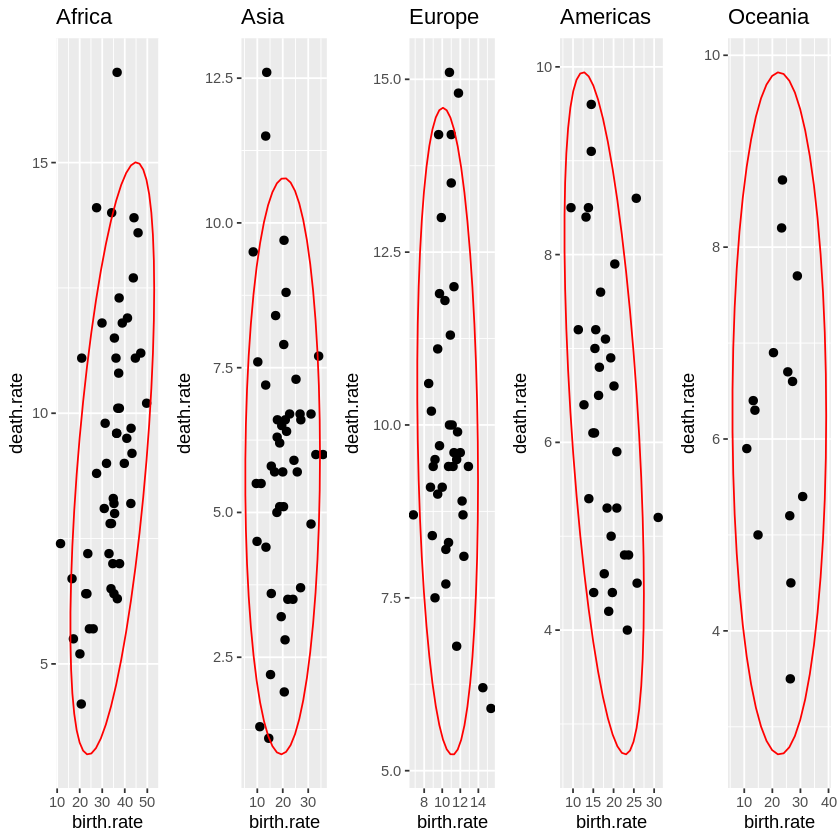

In [36]:
library(grid)

africa   <- subset(countries, continent == "Africa")
asia     <- subset(countries, continent == "Asia")
europe   <- subset(countries, continent == "Europe")
america  <- subset(countries, continent == "Americas")
oceania  <- subset(countries, continent == "Oceania")

make_plot <- function(dat, title_text) {
  ggplot(dat, aes(x = birth.rate, y = death.rate)) +
    geom_point(size = 2) +
    stat_ellipse(color = "red") +
    ggtitle(title_text)
}

p1 <- make_plot(africa, "Africa")
p2 <- make_plot(asia, "Asia")
p3 <- make_plot(europe, "Europe")
p4 <- make_plot(america, "Americas")
p5 <- make_plot(oceania, "Oceania")

grid.newpage()
pushViewport(viewport(layout = grid.layout(1, 5)))

print(p1, vp = viewport(layout.pos.row = 1, layout.pos.col = 1))
print(p2, vp = viewport(layout.pos.row = 1, layout.pos.col = 2))
print(p3, vp = viewport(layout.pos.row = 1, layout.pos.col = 3))
print(p4, vp = viewport(layout.pos.row = 1, layout.pos.col = 4))
print(p5, vp = viewport(layout.pos.row = 1, layout.pos.col = 5))

The file wine.csv contains the monthly sales of Australian wine by category in thousands of liters, from January 1980 to July 1995. Find the mean value of sales in each category for the time between January 1980 and December 1987, and between January 1988 and July 1995 separatly and create with ggplot a wheel chart with two layers: the first with the mean sale from 1988 to 1995, and the second for data from 1980 to 1987. Place the second layer on top of the first and create a proper legend.

In [ ]:
wine = read.csv2('Data/wine.csv')
wine

winet,fortw,dryw,sweetw,red,rose,spark
<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,2585,1954,85,464,112,1686
2,3368,2302,89,675,118,1591
3,3210,3054,109,703,129,2304
4,3111,2414,95,887,99,1712
5,3756,2226,91,1139,116,1471
6,4216,2725,95,1077,168,1377
7,5225,2589,96,1318,118,1966
8,4426,3470,128,1260,129,2453
9,3932,2400,124,1120,205,1984


In [47]:
wine$date <- seq(as.Date("1980-01-01"), by = "month", length.out = 187)
wine

winet,fortw,dryw,sweetw,red,rose,spark,date
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<date>
1,2585,1954,85,464,112,1686,1980-01-01
2,3368,2302,89,675,118,1591,1980-02-01
3,3210,3054,109,703,129,2304,1980-03-01
4,3111,2414,95,887,99,1712,1980-04-01
5,3756,2226,91,1139,116,1471,1980-05-01
6,4216,2725,95,1077,168,1377,1980-06-01
7,5225,2589,96,1318,118,1966,1980-07-01
8,4426,3470,128,1260,129,2453,1980-08-01
9,3932,2400,124,1120,205,1984,1980-09-01


The file Per.csv contains the heights of baby brothers and sisters in different families. Clear the data and, using `ggplot`, create a graph that shows the density plots for heights depending on gender with pointing out the mean and using different colors.


In [ ]:
install.packages('e1071')
library('e1071')

Per = read.csv2('Data/Per.csv')
Per = data.frame(e1071::impute(Per))
Per

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’



Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element




family,brother,sister
<int>,<int>,<int>
1,71,69
2,68,64
3,66,65
4,67,63
5,70,65
6,71,62
7,70,65
8,73,64
9,72,66


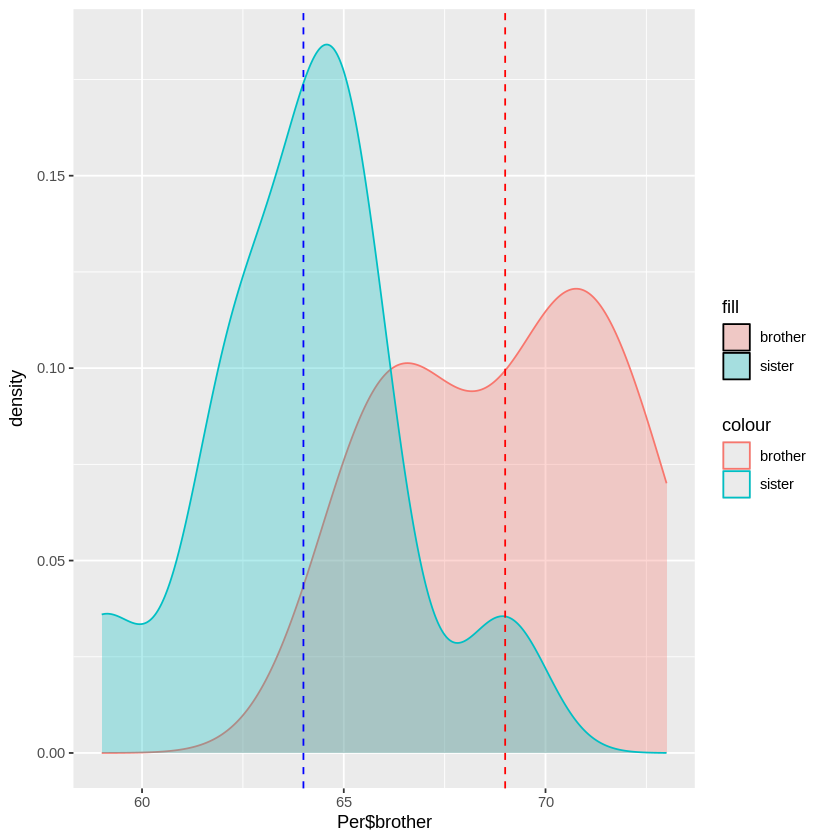

In [40]:
ggplot() +
  geom_density(aes(x = Per$brother, color = "brother", fill = "brother"), alpha = 0.3) +
  geom_density(aes(x = Per$sister, color = "sister", fill = "sister"), alpha = 0.3) +
  geom_vline(xintercept = mean(Per$brother, na.rm = TRUE), color = "red", linetype = "dashed") +
  geom_vline(xintercept = mean(Per$sister, na.rm = TRUE), color = "blue", linetype = "dashed")

At the end we would like to compare the ease and results of using the ggplot2 package and the lattice package. The file ap.csv which contains data from the variable apartments from the PBImisc library, and contains information about apartment offers in Warsaw in years 2007-2009. Please draw a box-whiskers plot of the prices of the apartments depending on the district they are from. Try to use different colors for each district.





In [ ]:
ap = read.csv2('Data/ap.csv')
ap

year,month,surface,city,district,street,n.rooms,floor,construction.date,type,offer.price,transaction.price,m2.price,condition,lat,lon
<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>
2008,1,20,Warszawa,Srodmiescie,Bagno,1,7,1970,hipoteczne,NA,210000,10500,do remontu,52.22947,21.00761
2008,1,25,Warszawa,Pruszkow,Pruszkow,1,1,1965,spoldzielcze,NA,175000,7000,do remontu,52.17162,20.80639
2008,1,26,Warszawa,Bielany,Marymoncka,1,6,1964,hipoteczne,NA,218000,8384,do remontu,52.27114,20.95003
2008,1,27,Warszawa,Wola,Sienna,1,1,1962,spoldzielcze,NA,230000,8518,dobry,52.24238,20.98659
2008,1,28,Warszawa,Mokotow,Raclawicka,1,1,1950,hipoteczne,250000,245000,8750,do remontu,52.19814,21.01752
2008,1,28,Warszawa,Mokotow,Miaczynska,2,4,1968,spoldzielcze,NA,245000,8750,dobry,52.19814,21.01752
2008,1,30,Warszawa,Srodmiescie,Pl. Konstytucji,1,1,1952,hipoteczne,320000,320000,10666,dobry,52.22947,21.00761
2008,1,32,Warszawa,Mokotow,Chelmska,2,3,2007,hipoteczne,394000,392000,12250,do wykonczenia,52.19814,21.01752
2008,1,32,Warszawa,Srodmiescie,Al.Solidarnosci,1,7,1961,hipoteczne,NA,290000,9062,bardzo dobry,52.22947,21.00761


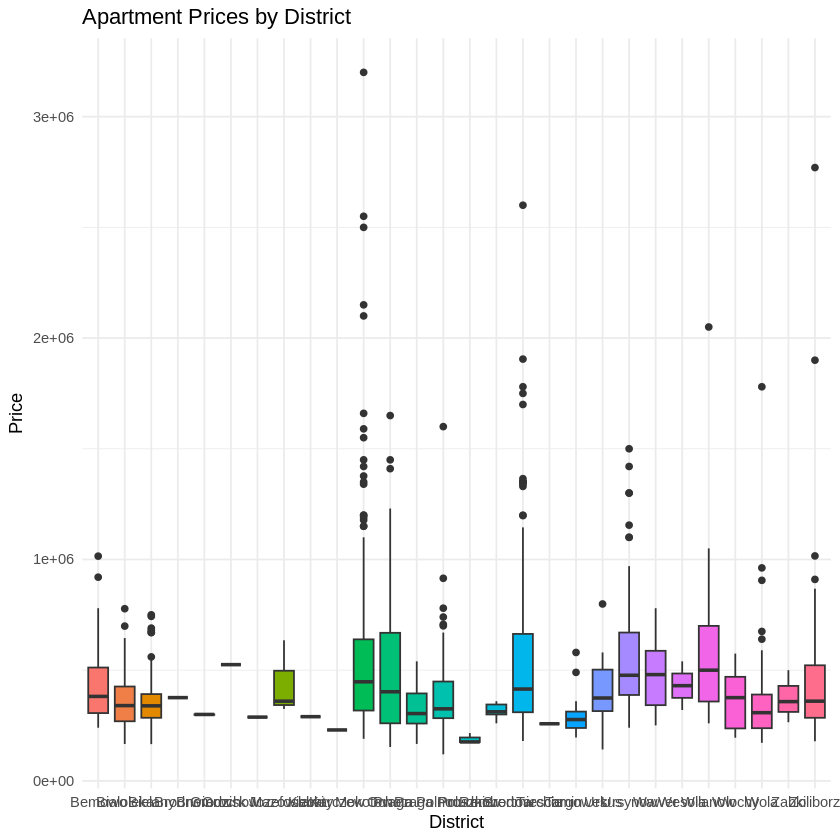

In [46]:
ggplot(ap, aes(x = district, y = transaction.price, fill = district)) +
  geom_boxplot() +
  theme_minimal() +
  labs(
    title = "Apartment Prices by District",
    x = "District",
    y = "Price"
  ) +
  theme(legend.position = "none")